In [6]:
   # DATA LOADING AND INSPECTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv(r'C:\Users\User\Downloads\DATA ANALYSIS PORTFOLIO\5 WATER PROJECTS\SACCO LOAN DEFAULT PREDICTION\kenya_sacco_credit_risk_portfolio.csv')

In [7]:
data.head()
# the first five rows

,loan_id,borrower_id,application_date,branch,county,age,employment_type,monthly_income_kes,membership_years,savings_balance_kes,...,mobile_money_active_months,utility_payment_consistency,income_consistency_score,days_overdue,late_payment_count_current,repayment_ratio,loan_status,default,generated_default_probability,risk_category
0,5009570,109570,2024-01-01,Nairobi CBD,Nairobi,21,Casual,28600,2,44900,...,22,0.753,0.642,6,0,0.873,Late,0,0.0260,Low
1,5046553,146553,2024-01-01,Nyeri,Kakamega,45,Salaried,50400,5,91400,...,53,0.754,0.940,3,0,0.965,Current,0,0.0649,Low
2,5000353,100353,2024-01-01,Kisumu,Nairobi,50,Business Owner,64200,8,174700,...,93,0.777,0.938,1,0,0.833,Current,0,0.0229,Low
3,5013827,113827,2024-01-01,Meru,Kisumu,27,Self-Employed,52900,1,223200,...,11,0.747,0.735,3,0,0.882,Late,0,0.0715,Low
4,5008668,108668,2024-01-01,Westlands,Uasin Gishu,53,Salaried,117000,2,309300,...,21,1.000,1.000,4,3,1.018,Late,0,0.0487,Low


In [8]:
data.shape
# 50000 rows and 32 columns

(50000, 32)

In [9]:
   # INSPECT THE TARGET VARIABLE
# our target variable = default( 0 = non-default and 1 = default)
data['default'].value_counts()

# The number of non-defaults(0) = 45217
# The number of defaults(1) = 4783

default
0    45217
1     4783
Name: count, dtype: int64

In [10]:
data['default'].value_counts(normalize = True) * 100

# default rate = 9.6%
# non-default rate = 90.43%

# remember, there are 50000 loans(100%) and default rate is roughly 10%(5000 loans).
# the ratio of defaulted loans to total loans(5000:50000) is 1:10
# this means in every 10 loans, 1 loan will be defaulted

default
0    90.434
1     9.566
Name: proportion, dtype: float64

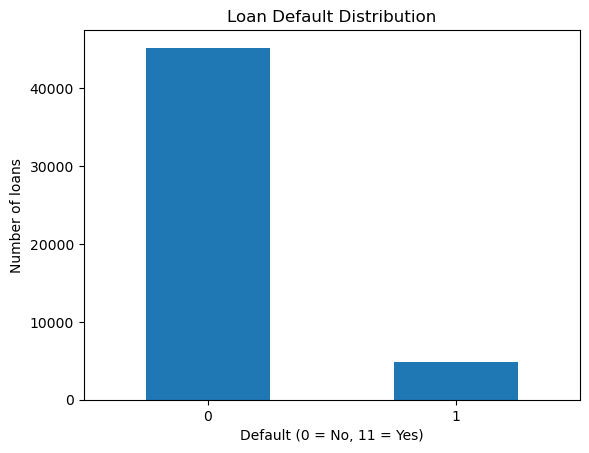

In [11]:
# visualize default distribution
data['default'].value_counts().plot(kind='bar')
plt.title('Loan Default Distribution')
plt.xlabel('Default (0 = No, 11 = Yes)')
plt.ylabel('Number of loans')
plt.xticks(rotation=0)
plt.show()

In [12]:
  # CREATE A CLEANER DEFAULT RATE TABLE
default_summary = (
    data['default']
    .value_counts()
    .rename(index={0: 'Non-Default', 1: 'Default'})
    .to_frame('Number_of_Loans')
)

default_summary['Percentage'] = (
    default_summary['Number_of_Loans'] /
    default_summary['Number_of_Loans'].sum() * 100
)

default_summary

,Number_of_Loans,Percentage
default,,
Non-Default,45217,90.434
Default,4783,9.566


In [13]:
  # Business interpretation
# For the SACCO, the 9.57% default rate becomes our baseline.
# Later, when we build the ML model, we won't simply ask: "How accurate is the model?"
# We'll ask more important questions such as: How well can the model identify the 9.57% of borrowers who default?
# That's where precision, recall, F1-score, ROC-AUC, and the confusion matrix become important.


In [14]:

  # BIVARIATE ANALYSIS


# NUMBER OF DEFAULTS BY LOAN PRODUCT
# we use groupby() function when checking the relationship/comparison between two variables
data.groupby('loan_product')['default'].agg(['count','sum','mean']).sort_values('mean', ascending=False)

,count,sum,mean
loan_product,,,
School Fees,7048,950,0.134790
Emergency,7846,1032,0.131532
Agriculture,7113,674,0.094756
Business,9972,851,0.085339
Development,11989,879,0.073317
Asset Finance,6032,397,0.065816


In [15]:
#  DEFAULT RATE BY LOAN PRODUCT

loan_products_default_count = (
    data.groupby('loan_product')['default']
    .agg(['count', 'sum', 'mean'])
)

loan_products_default_count['default_rate_%'] = loan_products_default_count['mean']*100

loan_products_default_count.sort_values('default_rate_%', ascending=False)

,count,sum,mean,default_rate_%
loan_product,,,,
School Fees,7048,950,0.134790,13.479001
Emergency,7846,1032,0.131532,13.153199
Agriculture,7113,674,0.094756,9.475608
Business,9972,851,0.085339,8.533895
Development,11989,879,0.073317,7.331721
Asset Finance,6032,397,0.065816,6.581565


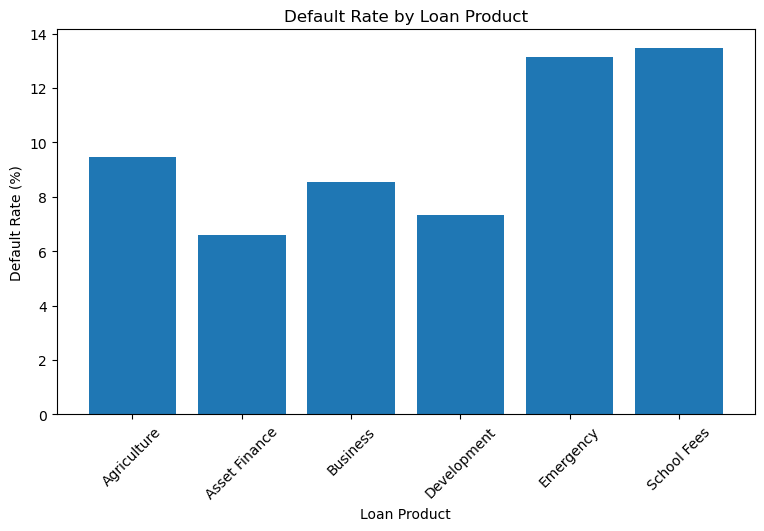

In [16]:
plt.figure(figsize=(9,5))

plt.bar(
    loan_products_default_count.index,
    loan_products_default_count['default_rate_%']
)

plt.title('Default Rate by Loan Product')
plt.xlabel('Loan Product')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [17]:
# NUMBER OF DEFAULTS BY EMPLOYMENT TYPE
data.groupby('employment_type')['default'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False)

,count,sum,mean
employment_type,,,
Casual,4424,567,0.128165
Farmer,5979,606,0.101355
Business Owner,9027,843,0.093387
Self-Employed,13479,1245,0.092366
Salaried,17091,1522,0.089053


In [18]:
# DEFAULT RATE BY EMPLOYMENT TYPE
employment_type_default_count = (
    data.groupby('employment_type')['default']
    .agg(['count','sum','mean'])
)

employment_type_default_count['default_rate_%'] = employment_type_default_count['mean']*100

employment_type_default_count.sort_values('default_rate_%', ascending=False)


,count,sum,mean,default_rate_%
employment_type,,,,
Casual,4424,567,0.128165,12.816456
Farmer,5979,606,0.101355,10.135474
Business Owner,9027,843,0.093387,9.338651
Self-Employed,13479,1245,0.092366,9.236590
Salaried,17091,1522,0.089053,8.905272


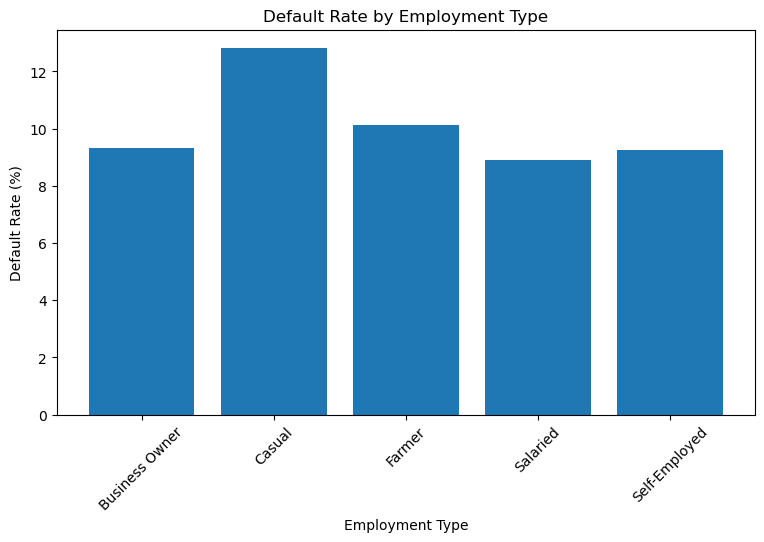

In [19]:
plt.figure(figsize=(9,5))

plt.bar(
    employment_type_default_count.index,
    employment_type_default_count['default_rate_%']
)

plt.title('Default Rate by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [20]:
# LOAN AMOUNT VS DEFAULT
data.groupby('default')['loan_amount_kes'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
default,,,,,,
0,45217,313542.813544,271500.0,185200.584546,16600,1000000
1,4783,345318.921179,299900.0,211601.990875,13000,1000000


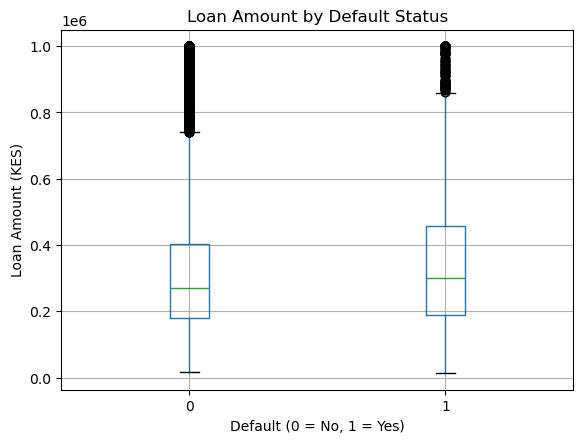

In [21]:
#plt.figure(figsize=(8,5))

data.boxplot(
    column='loan_amount_kes',
    by='default'
)

plt.title('Loan Amount by Default Status')
plt.suptitle('')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Loan Amount (KES)')

plt.show()

In [22]:
# NUMBER OF DEFAULTS BY COUNTY
data.groupby('county')['default'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False)

,count,sum,mean
county,,,
Nyeri,2008,203,0.101096
Kakamega,2582,260,0.100697
Kiambu,5060,507,0.100198
Machakos,3333,327,0.098110
Nakuru,4563,445,0.097524
Kisumu,3033,295,0.097263
Uasin Gishu,3061,297,0.097027
Meru,3467,335,0.096625
Embu,2516,234,0.093005


In [23]:
# DEFAULT RATE BY COUNTY
county_default_count = (
    data.groupby('county')['default']
      .agg(['count', 'sum', 'mean'])
)

county_default_count['default_rate_%'] = (
    county_default_count['mean'] * 100
)

county_default_count.sort_values(
    'default_rate_%',
    ascending=False
)

,count,sum,mean,default_rate_%
county,,,,
Nyeri,2008,203,0.101096,10.109562
Kakamega,2582,260,0.100697,10.069713
Kiambu,5060,507,0.100198,10.019763
Machakos,3333,327,0.098110,9.810981
Nakuru,4563,445,0.097524,9.752356
Kisumu,3033,295,0.097263,9.726344
Uasin Gishu,3061,297,0.097027,9.702712
Meru,3467,335,0.096625,9.662532
Embu,2516,234,0.093005,9.300477


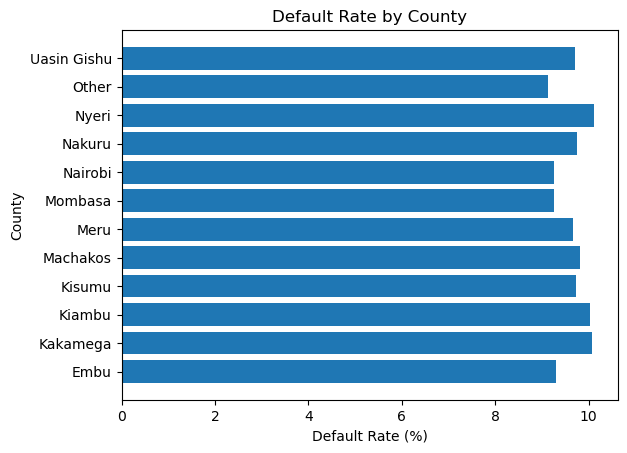

In [24]:


#plt.figure(figsize=(10,8))

plt.barh(
    county_default_count.index,
    county_default_count['default_rate_%']
)

plt.title('Default Rate by County')
plt.xlabel('Default Rate (%)')
plt.ylabel('County')

plt.show()

In [25]:
#INCOME VS DEFAULT
data.groupby('default')['monthly_income_kes'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
default,,,,,,
0,45217,64734.827609,59500.0,30658.453057,10000,365400
1,4783,63923.938950,58300.0,31479.322275,10000,322100


<Figure size 800x500 with 0 Axes>

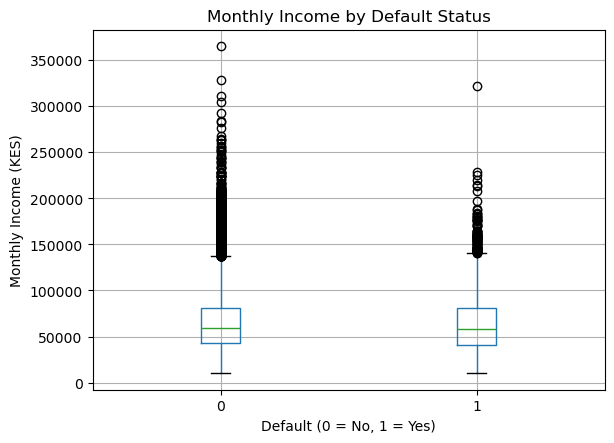

In [26]:
plt.figure(figsize=(8,5))

data.boxplot(
    column='monthly_income_kes',
    by='default'
)

plt.title('Monthly Income by Default Status')
plt.suptitle('')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Monthly Income (KES)')

plt.show()

In [27]:
previous_default_analysis = (
    data.groupby('previous_defaults')['default']
      .agg(['count', 'sum', 'mean'])
)

previous_default_analysis['default_rate_%'] = (
    previous_default_analysis['mean'] * 100
)

previous_default_analysis

,count,sum,mean,default_rate_%
previous_defaults,,,,
0,39743,3604,0.090683,9.068264
1,8979,995,0.110814,11.081412
2,1149,158,0.137511,13.751088
3,116,24,0.206897,20.689655
4,12,2,0.166667,16.666667
5,1,0,0.000000,0.000000


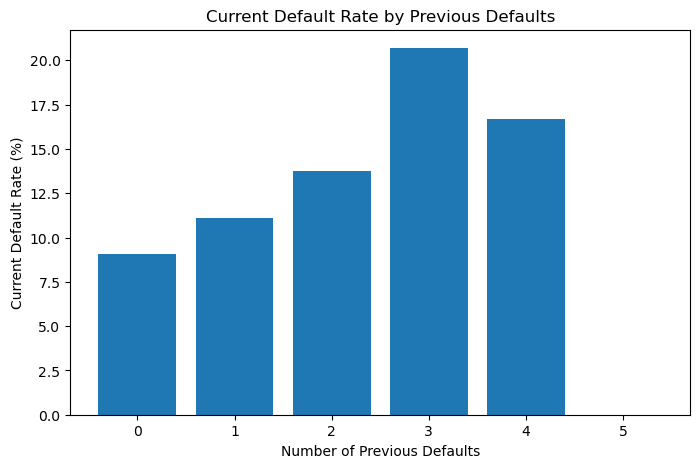

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    previous_default_analysis.index.astype(str),
    previous_default_analysis['default_rate_%']
)

plt.title('Current Default Rate by Previous Defaults')
plt.xlabel('Number of Previous Defaults')
plt.ylabel('Current Default Rate (%)')

plt.show()

In [29]:
# PREVIOUS LATE PAYMENTS VS CURRENT DEFAULT
late_payment_analysis = (
    data.groupby('previous_late_payments')['default']
      .agg(['count', 'sum', 'mean'])
)

late_payment_analysis['default_rate_%'] = (
    late_payment_analysis['mean'] * 100
)

late_payment_analysis

,count,sum,mean,default_rate_%
previous_late_payments,,,,
0,19986,1885,0.094316,9.431602
1,17595,1634,0.092867,9.286729
2,8545,851,0.099590,9.959040
3,2931,309,0.105425,10.542477
4,718,74,0.103064,10.306407
5,183,27,0.147541,14.754098
6,35,3,0.085714,8.571429
7,6,0,0.000000,0.000000
9,1,0,0.000000,0.000000


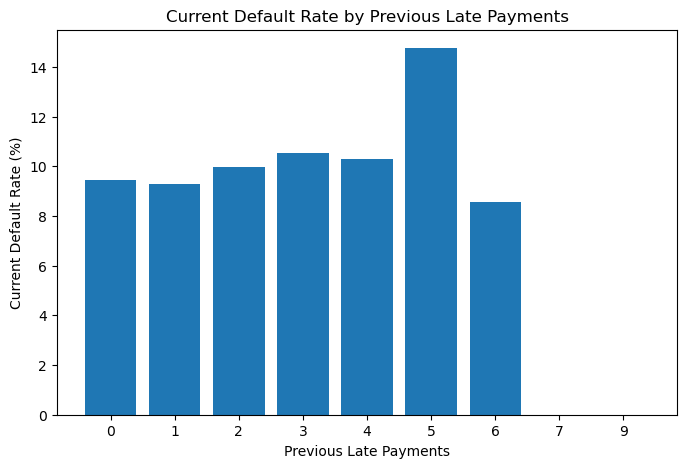

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    late_payment_analysis.index.astype(str),
    late_payment_analysis['default_rate_%']
)

plt.title('Current Default Rate by Previous Late Payments')
plt.xlabel('Previous Late Payments')
plt.ylabel('Current Default Rate (%)')

plt.show()

In [31]:
# SAVINGS BALANCE VS DEFAULT
data.groupby('default')['savings_balance_kes'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
default,,,,,,
0,45217,197987.913838,165800.0,140219.261901,1000,1459300
1,4783,133829.918461,93000.0,129240.907828,1000,893600


In [32]:
# OTHER DEBT VS DEFAULT
data.groupby('default')['other_monthly_debt_kes'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
default,,,,,,
0,45217,11897.722096,9900.0,8844.052260,300,99200
1,4783,12199.958185,10000.0,9026.593685,300,66300


In [33]:
# SEPARATE NUMERICAL AND CATEGORICAL VARIABLES
# Numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

numerical_cols

Index(['loan_id', 'borrower_id', 'age', 'monthly_income_kes',
       'membership_years', 'savings_balance_kes', 'loan_amount_kes',
       'loan_term_months', 'monthly_repayment_kes', 'other_monthly_debt_kes',
       'debt_to_income_ratio', 'loan_to_savings_ratio', 'previous_loans',
       'previous_defaults', 'previous_late_payments',
       'avg_monthly_inflows_kes', 'avg_monthly_outflows_kes',
       'mobile_money_active_months', 'utility_payment_consistency',
       'income_consistency_score', 'days_overdue',
       'late_payment_count_current', 'repayment_ratio', 'default',
       'generated_default_probability'],
      dtype='object')

In [34]:
# Categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns

categorical_cols

Index(['application_date', 'branch', 'county', 'employment_type',
       'loan_product', 'loan_status', 'risk_category'],
      dtype='object')

In [35]:
# NUMERICAL UNIVARIATE ANALYSIS
data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,50000.0,5.025000e+06,14433.901067,5.000001e+06,5.012501e+06,5.025000e+06,5.037500e+06,5050000.00
borrower_id,50000.0,1.250005e+05,14433.901067,1.000010e+05,1.125008e+05,1.250005e+05,1.375002e+05,150000.00
age,50000.0,3.713746e+01,8.690509,2.100000e+01,3.100000e+01,3.700000e+01,4.300000e+01,65.00
monthly_income_kes,50000.0,6.465726e+04,30738.530135,1.000000e+04,4.280000e+04,5.940000e+04,8.060000e+04,365400.00
membership_years,50000.0,5.009140e+00,3.164752,0.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00,20.00
savings_balance_kes,50000.0,1.918506e+05,140478.531476,1.000000e+03,8.680000e+04,1.596000e+05,2.632250e+05,1459300.00
loan_amount_kes,50000.0,3.165825e+05,188116.668668,1.300000e+04,1.797000e+05,2.739000e+05,4.081250e+05,1000000.00
loan_term_months,50000.0,1.848576e+01,14.069732,3.000000e+00,6.000000e+00,1.200000e+01,2.400000e+01,60.00
monthly_repayment_kes,50000.0,3.698308e+04,43204.064126,3.000000e+02,1.060000e+04,2.180000e+04,4.580000e+04,406500.00
other_monthly_debt_kes,50000.0,1.192663e+04,8862.031096,3.000000e+02,5.200000e+03,9.900000e+03,1.640000e+04,99200.00


In [36]:
# CATEGORICAL UNIVARIATE ANALYSIS
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(data[col].value_counts())


application_date
application_date
2025-12-31    77
2026-01-07    75
2026-08-12    70
2024-10-31    69
2025-08-26    68
              ..
2025-09-28    34
2024-12-06    34
2024-07-05    34
2025-01-19    33
2025-03-28    33
Name: count, Length: 974, dtype: int64

branch
branch
Nakuru         5115
Meru           5083
Nyeri          5051
Westlands      5050
Embu           4982
Nairobi CBD    4961
Eldoret        4961
Thika          4959
Kisumu         4922
Mombasa        4916
Name: count, dtype: int64

county
county
Nairobi        12498
Kiambu          5060
Nakuru          4563
Other           4360
Mombasa         3519
Meru            3467
Machakos        3333
Uasin Gishu     3061
Kisumu          3033
Kakamega        2582
Embu            2516
Nyeri           2008
Name: count, dtype: int64

employment_type
employment_type
Salaried          17091
Self-Employed     13479
Business Owner     9027
Farmer             5979
Casual             4424
Name: count, dtype: int64

loan_product
loan_product

In [37]:
correlation_matrix = data[numerical_cols].corr()

correlation_matrix

,loan_id,borrower_id,age,monthly_income_kes,membership_years,savings_balance_kes,loan_amount_kes,loan_term_months,monthly_repayment_kes,other_monthly_debt_kes,...,avg_monthly_inflows_kes,avg_monthly_outflows_kes,mobile_money_active_months,utility_payment_consistency,income_consistency_score,days_overdue,late_payment_count_current,repayment_ratio,default,generated_default_probability
loan_id,1.000000,1.000000,-0.004792,-0.003064,0.005236,0.000313,-0.003627,0.001148,-0.003821,-0.004442,...,-0.002888,-0.004000,0.005347,0.003935,0.000050,0.004065,-0.001559,-0.004467,0.000564,-0.004527
borrower_id,1.000000,1.000000,-0.004792,-0.003064,0.005236,0.000313,-0.003627,0.001148,-0.003821,-0.004442,...,-0.002888,-0.004000,0.005347,0.003935,0.000050,0.004065,-0.001559,-0.004467,0.000564,-0.004527
age,-0.004792,-0.004792,1.000000,-0.006274,-0.008628,-0.002004,-0.008233,0.011451,-0.008385,-0.000776,...,-0.004809,-0.005411,-0.009856,-0.003523,-0.002564,-0.002188,-0.003967,-0.002513,0.000458,0.000137
monthly_income_kes,-0.003064,-0.003064,-0.006274,1.000000,0.003983,0.659443,0.767018,0.003123,0.384906,0.639470,...,0.955930,0.924729,0.004912,-0.003492,0.078326,-0.005315,-0.009520,0.006964,-0.007759,-0.022109
membership_years,0.005236,0.005236,-0.008628,0.003983,1.000000,0.002833,-0.001711,0.009862,-0.004817,0.004825,...,0.004033,0.004274,0.974602,0.000047,-0.000406,-0.071853,-0.055339,0.077915,-0.089893,-0.173008
savings_balance_kes,0.000313,0.000313,-0.002004,0.659443,0.002833,1.000000,0.687144,0.000010,0.343834,0.422052,...,0.629127,0.606379,0.004035,-0.003063,0.053352,-0.112087,-0.090731,0.117736,-0.134331,-0.265512
loan_amount_kes,-0.003627,-0.003627,-0.008233,0.767018,-0.001711,0.687144,1.000000,0.001090,0.502782,0.491454,...,0.731993,0.707932,-0.001371,-0.009185,0.061019,0.042464,0.030671,-0.041036,0.049683,0.082953
loan_term_months,0.001148,0.001148,0.011451,0.003123,0.009862,0.000010,0.001090,1.000000,-0.536250,0.003365,...,0.004082,0.003018,0.009195,-0.005994,-0.007532,-0.068622,-0.055054,0.069212,-0.083739,-0.171786
monthly_repayment_kes,-0.003821,-0.003821,-0.008385,0.384906,-0.004817,0.343834,0.502782,-0.536250,1.000000,0.242725,...,0.363923,0.353420,-0.004322,0.005672,0.034395,0.114962,0.088850,-0.115393,0.137067,0.270418
other_monthly_debt_kes,-0.004442,-0.004442,-0.000776,0.639470,0.004825,0.422052,0.491454,0.003365,0.242725,1.000000,...,0.610515,0.589822,0.004850,-0.001994,0.043630,0.008492,0.001966,-0.009364,0.010031,0.008327


In [38]:
data['default'].corr(data['loan_amount_kes'])

np.float64(0.04968311534903406)

In [39]:
data['default'].corr(data['previous_defaults'])

np.float64(0.03784454836033533)

In [40]:
data['default'].corr(data['previous_late_payments'])

np.float64(0.011189252641008871)

In [41]:
data['default'].corr(data['monthly_income_kes'])

np.float64(-0.007759138988570828)

In [42]:
data['default'].corr(data['other_monthly_debt_kes'])

np.float64(0.010031097543155244)

In [43]:
data['default'].corr(data['savings_balance_kes'])


np.float64(-0.13433099415476127)

In [44]:
#FEATURE ENGINEERING
#How large is the loan compared with income?
#Loan-to-Income Ratio

data['loan_to_income_ratio'] = (
    data['loan_amount_kes'] / data['monthly_income_kes']
)

In [45]:
# Debt-to-Income Ratio(DTI).
# Are borrowers who already have higher debt obligations relative to their income more likely to default?
data['debt_to_income_ratio'] = (
    data['other_monthly_debt_kes'] / data['monthly_income_kes']
)

In [46]:
# Total_Debt-to-Income Ratio(DTI).
# After taking this new loan, how much of the borrower's monthly income would be committed to debt payments?
data['total_debt_service_ratio'] = (
    (data['other_monthly_debt_kes'] + data['monthly_repayment_kes'])
    / data['monthly_income_kes']
)

In [47]:
# Monthly Cash Flow
# Do borrowers with weaker monthly cash flow have higher observed default rates?
data['monthly_cash_flow'] = (
    data['avg_monthly_inflows_kes']
    - data['avg_monthly_outflows_kes']
)

In [48]:
# Cash-Flow-to-Income Ratio
data['cash_flow_to_income_ratio'] = (
    data['monthly_cash_flow'] / data['monthly_income_kes']
)

In [49]:
# Repayment-to-Income Ratio
# Business question: Does a larger monthly repayment relative to income correspond with higher observed default rates?
data['repayment_to_income_ratio'] = (
    data['monthly_repayment_kes'] / data['monthly_income_kes']
)

In [50]:
# Savings-to-Income Ratio
# Do borrowers with stronger savings relative to income have different observed default rates?
data['savings_to_income_ratio'] = (
    data['savings_balance_kes'] / data['monthly_income_kes']
)

In [51]:
# Check the New Features
engineered_features = [
    'loan_to_income_ratio',
    'debt_to_income_ratio',
    'total_debt_service_ratio',
    'monthly_cash_flow',
    'cash_flow_to_income_ratio',
    'repayment_to_income_ratio',
    'savings_to_income_ratio'
]

data[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_to_income_ratio,50000.0,4.916455,1.739747,1.044077,3.600000,4.787789,6.069642,12.492337
debt_to_income_ratio,50000.0,0.184662,0.095575,0.018072,0.101852,0.184430,0.267559,0.352518
total_debt_service_ratio,50000.0,0.760318,0.577369,0.059937,0.385538,0.569096,0.932259,4.552732
monthly_cash_flow,50000.0,13160.684000,9925.769928,300.000000,5800.000000,10900.000000,18000.000000,121200.000000
cash_flow_to_income_ratio,50000.0,0.203907,0.108574,0.016598,0.111444,0.200508,0.289474,0.470948
repayment_to_income_ratio,50000.0,0.575656,0.569499,0.025180,0.191980,0.374007,0.731524,4.512071
savings_to_income_ratio,50000.0,2.960087,1.503106,0.013495,1.691205,2.968860,4.226686,7.721774


In [52]:
# Before interpreting the results, check whether your dataset contains any zero-income records.
# If there are zero-income records, division can produce problematic values. If there aren't any, we're fine.
(data['monthly_income_kes'] == 0).sum()

np.int64(0)

In [53]:
# COMPARE THESE FEATURES WITH DEFAULT
data.groupby('default')[engineered_features].agg(
    ['mean', 'median']
)

loan_to_income_ratio           debt_to_income_ratio            \
                        mean    median                 mean    median   
default                                                                 
0                   4.873722  4.727903             0.183951  0.183333   
1                   5.320432  5.306011             0.191389  0.194444   

        total_debt_service_ratio           monthly_cash_flow           \
                            mean    median              mean   median   
default                                                                 
0                       0.730187  0.554787      13192.754937  10900.0   
1                       1.045164  0.778870      12857.495296  10400.0   

        cash_flow_to_income_ratio           repayment_to_income_ratio  \
                             mean    median                      mean   
default                                                                 
0                        0.204285  0.200672                  0.546237   
1                        0.200335  0.198433                  0.853775   

                  savings_to_income_ratio            
           median                    mean    median  
default                                              
0        0.359107                3.057004  3.075697  
1        0.576923                2.043861  1.586207

In [54]:
# BIVARIATE ANALYSIS ACROSS LEVELS, NOT JUST ON AVERAGES AND MEDIAN

data['repayment_ratio_group'] = pd.cut(
    data['repayment_to_income_ratio'],
    bins=[0, 0.30, 0.50, 0.70, 1.00, float('inf')],
    labels=[
        '0-30%',
        '30-50%',
        '50-70%',
        '70-100%',
        '100%+'
    ]
)

repayment_risk = (
    data.groupby('repayment_ratio_group', observed=True)['default']
      .agg(['count', 'sum', 'mean'])
)

repayment_risk['default_rate_%'] = repayment_risk['mean'] * 100

repayment_risk

,count,sum,mean,default_rate_%
repayment_ratio_group,,,,
0-30%,20785,1377,0.066250,6.624970
30-50%,9854,756,0.076720,7.672011
50-70%,6151,617,0.100309,10.030889
70-100%,4888,506,0.103519,10.351882
100%+,8322,1527,0.183490,18.348955


In [55]:
data['debt_service_group'] = pd.cut(
    data['total_debt_service_ratio'],
    bins=[0, 0.30, 0.50, 0.70, 1.00, float('inf')],
    labels=[
        '0-30%',
        '30-50%',
        '50-70%',
        '70-100%',
        '100%+'
    ]
)

debt_service_risk = (
    data.groupby('debt_service_group', observed=True)['default']
      .agg(['count', 'sum', 'mean'])
)

debt_service_risk['default_rate_%'] = (
    debt_service_risk['mean'] * 100
)

debt_service_risk

,count,sum,mean,default_rate_%
debt_service_group,,,,
0-30%,6835,430,0.062911,6.291149
30-50%,14046,951,0.067706,6.770611
50-70%,9960,746,0.074900,7.489960
70-100%,8003,811,0.101337,10.133700
100%+,11156,1845,0.165382,16.538186


In [56]:
data['savings_ratio_group'] = pd.cut(
    data['savings_to_income_ratio'],
    bins=[0, 1, 2, 3, float('inf')],
    labels=[
        '0-100%',
        '100-200%',
        '200-300%',
        '300%+'
    ]
)

savings_risk = (
    data.groupby('savings_ratio_group', observed=True)['default']
      .agg(['count', 'sum', 'mean'])
)

savings_risk['default_rate_%'] = (
    savings_risk['mean'] * 100
)

savings_risk

,count,sum,mean,default_rate_%
savings_ratio_group,,,,
0-100%,5932,1748,0.294673,29.467296
100-200%,9658,984,0.101884,10.188445
200-300%,9725,639,0.065707,6.570694
300%+,24685,1412,0.057201,5.720073


In [57]:
# MODEL FEATURES SELECTION

# remove the leakage columns from the predictive features
leakage_columns = [
    'days_overdue',
    'late_payment_count_current',
    'repayment_ratio',
    'loan_status',
    'generated_default_probability',
    'risk_category'
]

In [58]:
# remove the target
target = data['default']

In [59]:
# create our feature columns
model_feature_columns = [
    # Borrower profile
    'age',
    'employment_type',
    'county',
    'membership_years',

    # Financial capacity
    'monthly_income_kes',
    'savings_balance_kes',
    'other_monthly_debt_kes',
    'avg_monthly_inflows_kes',
    'avg_monthly_outflows_kes',

    # Loan characteristics
    'loan_product',
    'loan_amount_kes',
    'loan_term_months',
    'monthly_repayment_kes',

    # Previous credit history
    'previous_loans',
    'previous_defaults',
    'previous_late_payments',

    # Financial/digital behavior
    'mobile_money_active_months',
    'utility_payment_consistency',
    'income_consistency_score',

    # Engineered features
    'loan_to_income_ratio',
    'debt_to_income_ratio',
    'total_debt_service_ratio',
    'monthly_cash_flow',
    'cash_flow_to_income_ratio',
    'repayment_to_income_ratio',
    'savings_to_income_ratio'
]

x = data[model_feature_columns]
y = data['default']

In [60]:
# Check it:
x. shape

# it has 50000 rows and 26 columns instead of the original 32 columns
# we have removed 6 columns that would result in data leakage abd left 
# with 26 columns/variables that can be used by the model for prediction

(50000, 26)

In [61]:
x.head()

,age,employment_type,county,membership_years,monthly_income_kes,savings_balance_kes,other_monthly_debt_kes,avg_monthly_inflows_kes,avg_monthly_outflows_kes,loan_product,...,mobile_money_active_months,utility_payment_consistency,income_consistency_score,loan_to_income_ratio,debt_to_income_ratio,total_debt_service_ratio,monthly_cash_flow,cash_flow_to_income_ratio,repayment_to_income_ratio,savings_to_income_ratio
0,21,Casual,Nairobi,2,28600,44900,800,27000,25700,Agriculture,...,22,0.753,0.642,2.388112,0.027972,0.444056,1300,0.045455,0.416084,1.569930
1,45,Salaried,Kakamega,5,50400,91400,9000,50400,35100,Development,...,53,0.754,0.940,7.208333,0.178571,0.414683,15300,0.303571,0.236111,1.813492
2,50,Business Owner,Nairobi,8,64200,174700,15700,84600,78700,Asset Finance,...,93,0.777,0.938,3.931464,0.244548,0.434579,5900,0.091900,0.190031,2.721184
3,27,Self-Employed,Kisumu,1,52900,223200,14700,48500,35900,Business,...,11,0.747,0.735,6.395085,0.277883,0.884688,12600,0.238185,0.606805,4.219282
4,53,Salaried,Uasin Gishu,2,117000,309300,23800,157700,150500,Development,...,21,1.000,1.000,5.725641,0.203419,0.391453,7200,0.061538,0.188034,2.643590


In [62]:
# check correlations among numerical features

numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
model_feature_correlations = x[numerical_features].corr()
model_feature_correlations

,age,membership_years,monthly_income_kes,savings_balance_kes,other_monthly_debt_kes,avg_monthly_inflows_kes,avg_monthly_outflows_kes,loan_amount_kes,loan_term_months,monthly_repayment_kes,...,mobile_money_active_months,utility_payment_consistency,income_consistency_score,loan_to_income_ratio,debt_to_income_ratio,total_debt_service_ratio,monthly_cash_flow,cash_flow_to_income_ratio,repayment_to_income_ratio,savings_to_income_ratio
age,1.000000,-0.008628,-0.006274,-0.002004,-0.000776,-0.004809,-0.005411,-0.008233,0.011451,-0.008385,...,-0.009856,-0.003523,-0.002564,-0.005055,0.003495,-0.008502,-0.000841,0.002137,-0.009206,0.001031
membership_years,-0.008628,1.000000,0.003983,0.002833,0.004825,0.004033,0.004274,-0.001711,0.009862,-0.004817,...,0.974602,0.000047,-0.000406,-0.003883,0.004299,-0.003760,0.001498,-0.001671,-0.004534,0.002057
monthly_income_kes,-0.006274,0.003983,1.000000,0.659443,0.639470,0.955930,0.924729,0.767018,0.003123,0.384906,...,0.004912,-0.003492,0.078326,-0.024347,-0.004464,-0.014107,0.619879,-0.007004,-0.013553,0.009945
savings_balance_kes,-0.002004,0.002833,0.659443,1.000000,0.422052,0.629127,0.606379,0.687144,0.000010,0.343834,...,0.004035,-0.003063,0.053352,0.242692,-0.004168,0.079691,0.414609,-0.001096,0.081491,0.684095
other_monthly_debt_kes,-0.000776,0.004825,0.639470,0.422052,1.000000,0.610515,0.589822,0.491454,0.003365,0.242725,...,0.004850,-0.001994,0.043630,-0.012798,0.691995,0.104260,0.398193,-0.002177,-0.010433,0.005083
avg_monthly_inflows_kes,-0.004809,0.004033,0.955930,0.629127,0.610515,1.000000,0.967298,0.731993,0.004082,0.363923,...,0.005412,-0.002769,0.075696,-0.024105,-0.004116,-0.015726,0.648646,0.057607,-0.015252,0.007991
avg_monthly_outflows_kes,-0.005411,0.004274,0.924729,0.606379,0.589822,0.967298,1.000000,0.707932,0.003018,0.353420,...,0.005610,-0.002134,0.074192,-0.022964,-0.004713,-0.014050,0.434391,-0.166631,-0.013453,0.006192
loan_amount_kes,-0.008233,-0.001711,0.767018,0.687144,0.491454,0.731993,0.707932,1.000000,0.001090,0.502782,...,-0.001371,-0.009185,0.061019,0.565040,-0.001189,0.193738,0.475176,-0.006742,0.196615,0.231385
loan_term_months,0.011451,0.009862,0.003123,0.000010,0.003365,0.004082,0.003018,0.001090,1.000000,-0.536250,...,0.009195,-0.005994,-0.007532,-0.001355,0.003728,-0.625447,0.005440,0.002751,-0.634716,-0.001049
monthly_repayment_kes,-0.008385,-0.004817,0.384906,0.343834,0.242725,0.363923,0.353420,0.502782,-0.536250,1.000000,...,-0.004322,0.005672,0.034395,0.285785,-0.003969,0.819938,0.231866,-0.009179,0.831935,0.115280


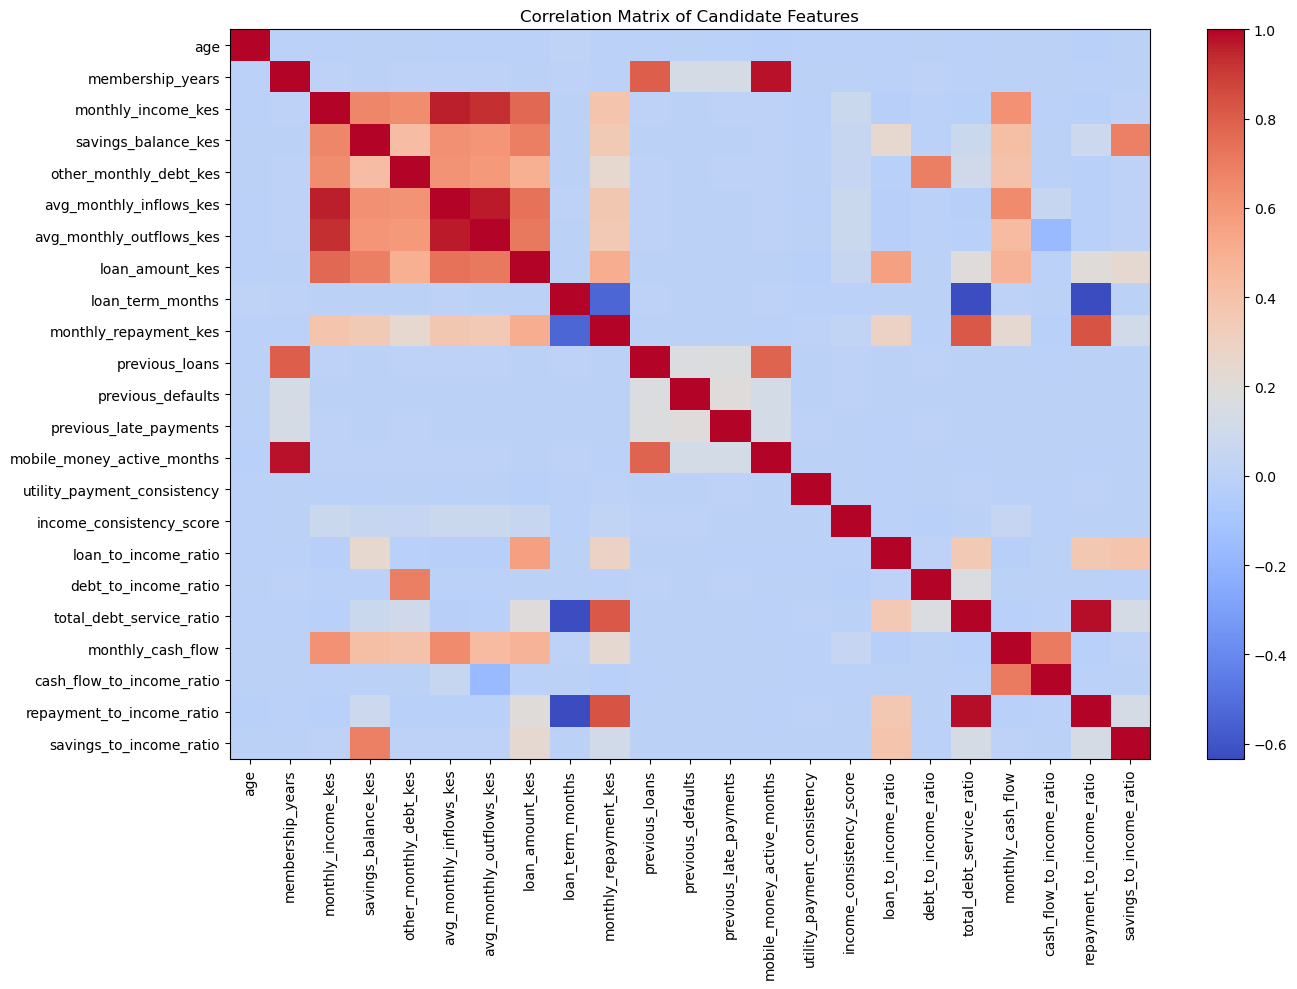

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.imshow(
    model_feature_correlations,
    cmap='coolwarm',
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(model_feature_correlations.columns)),
    model_feature_correlations.columns,
    rotation=90
)

plt.yticks(
    range(len(model_feature_correlations.columns)),
    model_feature_correlations.columns
)

plt.title('Correlation Matrix of Candidate Features')

plt.tight_layout()
plt.show()

In [64]:
# Identify highly correlated feature pairs
highly_correlated_features_pairs = (
    model_feature_correlations.abs()
    .where(model_feature_correlations.abs() > 0.80)
)

highly_correlated_features_pairs

,age,membership_years,monthly_income_kes,savings_balance_kes,other_monthly_debt_kes,avg_monthly_inflows_kes,avg_monthly_outflows_kes,loan_amount_kes,loan_term_months,monthly_repayment_kes,...,mobile_money_active_months,utility_payment_consistency,income_consistency_score,loan_to_income_ratio,debt_to_income_ratio,total_debt_service_ratio,monthly_cash_flow,cash_flow_to_income_ratio,repayment_to_income_ratio,savings_to_income_ratio
age,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_years,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.974602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income_kes,NaN,NaN,1.000000,NaN,NaN,0.955930,0.924729,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
savings_balance_kes,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_monthly_debt_kes,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_monthly_inflows_kes,NaN,NaN,0.955930,NaN,NaN,1.000000,0.967298,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_monthly_outflows_kes,NaN,NaN,0.924729,NaN,NaN,0.967298,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount_kes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_term_months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_repayment_kes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,NaN,NaN,NaN,NaN,0.819938,NaN,NaN,0.831935,NaN


In [65]:
#Install/import VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [66]:
# Select the numerical model features
numerical_features = x.select_dtypes(
    include=['int64', 'float64']
).columns

x_numeric = x[numerical_features]

In [67]:
# calculate vif
vif = pd.DataFrame()

vif['feature'] = x_numeric.columns

vif['VIF'] = [
    variance_inflation_factor(
        x_numeric.values,
        i
    )
    for i in range(x_numeric.shape[1])
]

vif = vif.sort_values('VIF', ascending=False)

vif

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
21,repayment_to_income_ratio,inf
19,monthly_cash_flow,inf
18,total_debt_service_ratio,inf
5,avg_monthly_inflows_kes,inf
6,avg_monthly_outflows_kes,inf
17,debt_to_income_ratio,inf
2,monthly_income_kes,111.648838
1,membership_years,75.693431
13,mobile_money_active_months,68.472572
7,loan_amount_kes,62.183513


In [68]:
model_features = [
    # Borrower profile
    'age',
    'employment_type',
    'county',
    'membership_years',

    # Financial capacity
    'monthly_income_kes',
    'monthly_cash_flow',
    'savings_to_income_ratio',

    # Loan characteristics
    'loan_to_income_ratio',
    'loan_term_months',
    'monthly_repayment_kes',

    # Previous credit history
    'previous_loans',
    'previous_defaults',
    'previous_late_payments',

    # Financial/digital behavior
    'utility_payment_consistency',
    'income_consistency_score',

    # Engineered overall debt burden
    'total_debt_service_ratio'
]

x_model = data[model_features]
y = data['default']

x_model.head()

# The training and testing data set(x) that the model will use are the features we have selected 
# after first doing basic bivariate analysis between selected variables among the 31 variables/columns and the target variable and looking for correlations
# then engineering more features from the the 31 variables that will answer key questions during loan application time by borrowers
# then doing bivariate analysis between the engineered features and the target variable and looking for their correlations.
# correlations show the relationshipbetween the features and the target, whether its positive or negative or no relationship at all
# we then do feature selection for the features the model will use. The model can not use all the 31 columns to do prediction during the application time
# it needs variables that will help predict default during the application time
# we tested for multicollinearity; identify variables that provide the same infrmation(overlapping) to the model that will make it hard for the model to choose which variable to work with
# we also did vif analysis to further identify the best columns to add to the model
# many times, we eliminated variables that were used to form a final ratio/feature because they will just overlap with final feature itself

,age,employment_type,county,membership_years,monthly_income_kes,monthly_cash_flow,savings_to_income_ratio,loan_to_income_ratio,loan_term_months,monthly_repayment_kes,previous_loans,previous_defaults,previous_late_payments,utility_payment_consistency,income_consistency_score,total_debt_service_ratio
0,21,Casual,Nairobi,2,28600,1300,1.569930,2.388112,6,11900,4,0,1,0.753,0.642,0.444056
1,45,Salaried,Kakamega,5,50400,15300,1.813492,7.208333,36,11900,9,0,1,0.754,0.940,0.414683
2,50,Business Owner,Nairobi,8,64200,5900,2.721184,3.931464,24,12200,16,0,0,0.777,0.938,0.434579
3,27,Self-Employed,Kisumu,1,52900,12600,4.219282,6.395085,12,32100,6,0,2,0.747,0.735,0.884688
4,53,Salaried,Uasin Gishu,2,117000,7200,2.643590,5.725641,36,22000,4,0,2,1.000,1.000,0.391453


In [69]:
# check the shape of the model training features(x_model)
x_model.shape

# it has 50000 rows/borrowers and 16 prediction columns/variables

(50000, 16)

In [70]:
# Separate numerical and categorical variables
model_numerical_features = x_model.select_dtypes(include=['int64', 'float64']).columns

In [71]:
model_categorical_features = x_model.select_dtypes(include=['object']).columns

In [72]:
print('Model Numerical Features:')
print(list(model_numerical_features))

print('\nModel Categorical Features:')
print(list(model_categorical_features))

Model Numerical Features:
['age', 'membership_years', 'monthly_income_kes', 'monthly_cash_flow', 'savings_to_income_ratio', 'loan_to_income_ratio', 'loan_term_months', 'monthly_repayment_kes', 'previous_loans', 'previous_defaults', 'previous_late_payments', 'utility_payment_consistency', 'income_consistency_score', 'total_debt_service_ratio']

Model Categorical Features:
['employment_type', 'county']


In [73]:
# Split into training and testing data
from sklearn.model_selection import train_test_split

# We'll use 80% training and 20% testing.

x_train, x_test, y_train, y_test = train_test_split(
    x_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [74]:
# Because only about 9.57% of your borrowers defaulted, we want the training and testing datasets to maintain approximately the same default proportion.
print('Training default rate:')
print(y_train.mean())

print('\nTesting default rate:')
print(y_test.mean())

Training default rate:
0.09565

Testing default rate:
0.0957


In [75]:
# ENCODE THE MODEL CATEGORICAL VARIABLES AND SCALE THE MODEL NUMERICAL COLUMNS
# Rather than manually encoding and scaling everything, we'll use Scikit-learn's ColumnTransformer and Pipeline. This is the cleaner professional approach because it prevents preprocessing information from accidentally leaking from the test set into the training process.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            model_numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            model_categorical_features
        )
    ]
)

# The preprocessing pipeline: Scales numerical variables, Converts categorical variables into 0/1 columns
# and Applies exactly the same transformations to future/test data


In [77]:
# Build the Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [78]:
# Because only about 9.57% of borrowers default, we'll initially use:
class_weight='balanced'
# This tells Logistic Regression to give more importance to the minority class (default = 1).


In [79]:
# Create the pipeline:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [80]:
# Then train it:
logistic_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
# Make predictions
# We'll generate both class predictions and probabilities.
# Class predictions
y_pred = logistic_model.predict(x_test)

# this produces 0 = predicted non-default and 1 = predicted default

In [82]:
# Default probabilities
# For example, the model might produce: Borrower A → 0.08, Borrower B → 0.31, Borrower C → 0.74
# Meaning the model estimates different probabilities of default.
y_prob = logistic_model.predict_proba(x_test)[:, 1]

In [83]:
# Evaluate the model
# Import the evaluation metrics:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [84]:
# Calculate the basic metrics:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.7179
Precision: 0.20965732087227415
Recall: 0.703239289446186
F1 Score: 0.3230141588672906
ROC-AUC: 0.7808098102286407


In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.72      0.82      9043
           1       0.21      0.70      0.32       957

    accuracy                           0.72     10000
   macro avg       0.58      0.71      0.57     10000
weighted avg       0.89      0.72      0.77     10000



In [86]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6506 2537]
 [ 284  673]]


In [87]:
# Test different probability thresholds
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_threshold),
        'recall': recall_score(y_test, y_pred_threshold),
        'f1_score': f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1_score
0,0.2,0.118622,0.957158,0.211084
1,0.3,0.137752,0.886102,0.238437
2,0.4,0.165734,0.804598,0.274853
3,0.5,0.209657,0.703239,0.323014
4,0.6,0.277442,0.575758,0.374448
5,0.7,0.357731,0.408568,0.381463
6,0.8,0.453125,0.212121,0.288968


In [88]:
# Find the threshold with the highest F1
best_threshold = threshold_df.loc[
    threshold_df['f1_score'].idxmax()
]

best_threshold

threshold    0.700000
precision    0.357731
recall       0.408568
f1_score     0.381463
Name: 5, dtype: float64

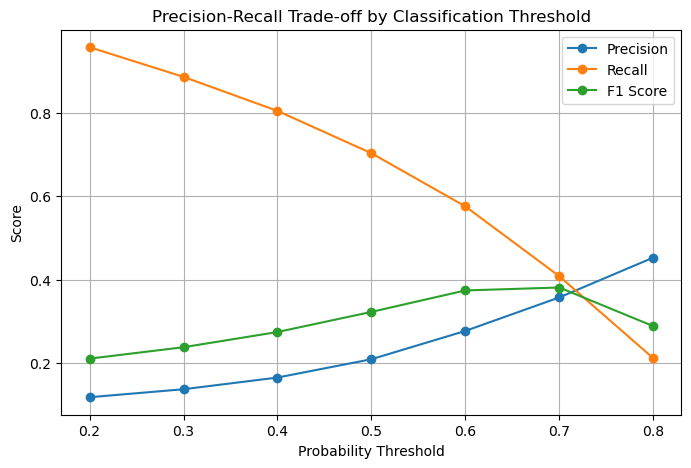

In [89]:
# Visualize the trade-off
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1_score'],
    marker='o',
    label='F1 Score'
)

plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off by Classification Threshold')
plt.legend()
plt.grid()
plt.show()

In [90]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gradient_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [91]:
# Then train
gradient_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [92]:
# Generate predictions
y_pred_gb = gradient_model.predict(x_test)

y_prob_gb = gradient_model.predict_proba(x_test)[:, 1]

In [93]:
# And evaluate
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)
print("ROC-AUC:", roc_auc_gb)

Accuracy: 0.9192
Precision: 0.7898832684824902
Recall: 0.21212121212121213
F1 Score: 0.3344316309719934
ROC-AUC: 0.8072047159796496


In [94]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

[[8989   54]
 [ 754  203]]


In [95]:
# test different thresholds for Gradient Boosting
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

gb_threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_gb >= threshold).astype(int)

    gb_threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_threshold),
        'recall': recall_score(y_test, y_pred_threshold),
        'f1_score': f1_score(y_test, y_pred_threshold)
    })

gb_threshold_df = pd.DataFrame(gb_threshold_results)

gb_threshold_df

,threshold,precision,recall,f1_score
0,0.1,0.284463,0.644723,0.394754
1,0.2,0.463734,0.407524,0.433815
2,0.3,0.607143,0.301985,0.403350
3,0.4,0.709677,0.252874,0.372881
4,0.5,0.789883,0.212121,0.334432
5,0.6,0.839806,0.180773,0.297506
6,0.7,0.879310,0.159875,0.270557
7,0.8,0.931034,0.141066,0.245009


In [96]:
# highest F1 among those thresholds
best_gb_threshold = gb_threshold_df.loc[
    gb_threshold_df['f1_score'].idxmax()
]

best_gb_threshold

threshold    0.200000
precision    0.463734
recall       0.407524
f1_score     0.433815
Name: 1, dtype: float64

In [97]:
# tuning the gradient boost model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.10],
    'classifier__max_depth': [2, 3, 4]
}

In [98]:
grid_search = GridSearchCV(
    estimator=gradient_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [99]:
# STEP 3 — RUN THE TUNING
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [100]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 200}


In [101]:
print("Best cross-validation ROC-AUC:")
print(grid_search.best_score_)

Best cross-validation ROC-AUC:
0.8049631345213769


In [102]:
# Get the tuned model
tuned_gb = grid_search.best_estimator_

In [103]:
# generate predictions on the test set
y_pred_tuned = tuned_gb.predict(x_test)

y_prob_tuned = tuned_gb.predict_proba(x_test)[:, 1]

In [104]:
# evaluate
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Accuracy:", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1 Score:", f1_tuned)
print("ROC-AUC:", roc_auc_tuned)

Accuracy: 0.918
Precision: 0.7665369649805448
Recall: 0.2058516196447231
F1 Score: 0.3245469522240527
ROC-AUC: 0.8066619706543138


In [105]:
# And the confusion matrix:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(cm_tuned)

[[8983   60]
 [ 760  197]]


In [106]:
# tuned model threshold analysis
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30,
              0.40, 0.50, 0.60, 0.70, 0.80]
tuned_threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

    tuned_threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(
            y_test,
            y_pred_threshold
        ),
        'recall': recall_score(
            y_test,
            y_pred_threshold
        ),
        'f1_score': f1_score(
            y_test,
            y_pred_threshold
        )
    })

tuned_threshold_df = pd.DataFrame(
    tuned_threshold_results
)
tuned_threshold_df

,threshold,precision,recall,f1_score
0,0.10,0.275524,0.645768,0.386250
1,0.15,0.374439,0.523511,0.436601
2,0.20,0.447172,0.437827,0.442450
3,0.25,0.514706,0.365726,0.427611
4,0.30,0.587549,0.315569,0.410605
5,0.40,0.679191,0.245559,0.360706
6,0.50,0.766537,0.205852,0.324547
7,0.60,0.848958,0.170324,0.283725
8,0.70,0.890909,0.153605,0.262032
9,0.80,0.938462,0.127482,0.224471


In [107]:
best_tuned_threshold = tuned_threshold_df.loc[
    tuned_threshold_df['f1_score'].idxmax()
]

best_tuned_threshold

threshold    0.200000
precision    0.447172
recall       0.437827
f1_score     0.442450
Name: 2, dtype: float64

In [108]:
# Step 1 — Create a validation set from the training data
from sklearn.model_selection import train_test_split

x_train_inner, x_val, y_train_inner, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Inner training:", x_train_inner.shape)
print("Validation:", x_val.shape)

Inner training: (32000, 16)
Validation: (8000, 16)


In [109]:
# Step 2 — Create the tuned Gradient Boosting model again
final_gb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=2,
                random_state=42
            )
        )
    ]
)

In [110]:
# Train it on the inner training set:
final_gb.fit(x_train_inner, y_train_inner)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
# Generate validation probabilities:
y_val_prob = final_gb.predict_proba(x_val)[:, 1]

In [112]:
# Test a wider range of thresholds:
thresholds = [
    0.05, 0.10, 0.15, 0.20,
    0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.60, 0.70
]

validation_results = []

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    validation_results.append({
        'threshold': threshold,
        'precision': precision_score(y_val, y_val_pred),
        'recall': recall_score(y_val, y_val_pred),
        'f1_score': f1_score(y_val, y_val_pred)
    })

validation_df = pd.DataFrame(validation_results)

validation_df

,threshold,precision,recall,f1_score
0,0.05,0.156558,0.830065,0.263431
1,0.10,0.260377,0.631373,0.368702
2,0.15,0.341615,0.503268,0.406977
3,0.20,0.434159,0.435294,0.434726
4,0.25,0.493805,0.364706,0.419549
5,0.30,0.563927,0.322876,0.410640
6,0.35,0.637143,0.291503,0.400000
7,0.40,0.690141,0.256209,0.373689
8,0.45,0.740741,0.235294,0.357143
9,0.50,0.775120,0.211765,0.332649


In [113]:
# best validation threshold
best_validation_threshold = validation_df.loc[
    validation_df['f1_score'].idxmax()
]

best_validation_threshold

threshold    0.200000
precision    0.434159
recall       0.435294
f1_score     0.434726
Name: 3, dtype: float64

In [114]:
# Retrain the final model
final_gb.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [115]:
# Generate probabilities for the untouched test set:
y_test_prob_final = final_gb.predict_proba(x_test)[:, 1]

In [116]:
# Apply the threshold selected from validation:
final_threshold = best_validation_threshold['threshold']

y_test_pred_final = (
    y_test_prob_final >= final_threshold
).astype(int)

In [117]:
# Step 5 — Final evaluation
final_accuracy = accuracy_score(
    y_test,
    y_test_pred_final
)

final_precision = precision_score(
    y_test,
    y_test_pred_final
)

final_recall = recall_score(
    y_test,
    y_test_pred_final
)

final_f1 = f1_score(
    y_test,
    y_test_pred_final
)

final_roc_auc = roc_auc_score(
    y_test,
    y_test_prob_final
)

print("Final threshold:", final_threshold)
print("Accuracy:", final_accuracy)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1 Score:", final_f1)
print("ROC-AUC:", final_roc_auc)

Final threshold: 0.2
Accuracy: 0.8944
Precision: 0.4471718249733191
Recall: 0.4378265412748171
F1 Score: 0.4424498416050686
ROC-AUC: 0.8066619706543138


In [118]:
# and the confusion matrix
final_cm = confusion_matrix(
    y_test,
    y_test_pred_final
)

print(final_cm)

[[8525  518]
 [ 538  419]]


In [119]:
# build the credit-risk scoring system
credit_scores = x_test.copy()

credit_scores['actual_default'] = y_test.values

credit_scores['default_probability'] = y_test_prob_final

credit_scores['risk_score'] = (
    y_test_prob_final * 100
)

In [120]:
# Create risk bands
credit_scores['risk_band'] = pd.cut(
    credit_scores['default_probability'],
    bins=[0, 0.10, 0.20, 1.00],
    labels=[
        'Low Risk',
        'Moderate Risk',
        'Higher Risk'
    ],
    include_lowest=True
)

In [121]:
# See the resulting borrowers
credit_scores[
    [
        'default_probability',
        'risk_score',
        'risk_band',
        'actual_default'
    ]
].head(20)

,default_probability,risk_score,risk_band,actual_default
44284,0.019664,1.966413,Low Risk,0
41181,0.125422,12.542157,Moderate Risk,0
6066,0.285688,28.568808,Higher Risk,1
21869,0.326630,32.663037,Higher Risk,0
29239,0.095072,9.507205,Low Risk,0
29079,0.026808,2.680761,Low Risk,0
42451,0.040424,4.042438,Low Risk,0
3000,0.051584,5.158430,Low Risk,0
31180,0.040842,4.084215,Low Risk,0
32911,0.055013,5.501345,Low Risk,0


In [122]:
# Analyze the risk bands
risk_summary = (
    credit_scores
    .groupby('risk_band', observed=True)
    .agg(
        borrowers=('default_probability', 'count'),
        average_probability=('default_probability', 'mean'),
        actual_defaults=('actual_default', 'sum'),
        actual_default_rate=('actual_default', 'mean')
    )
)

risk_summary

,borrowers,average_probability,actual_defaults,actual_default_rate
risk_band,,,,
Low Risk,7757,0.044754,339,0.043702
Moderate Risk,1306,0.137204,199,0.152374
Higher Risk,937,0.427195,419,0.447172


In [125]:
data.copy()

,loan_id,borrower_id,application_date,branch,county,age,employment_type,monthly_income_kes,membership_years,savings_balance_kes,...,risk_category,loan_to_income_ratio,total_debt_service_ratio,monthly_cash_flow,cash_flow_to_income_ratio,repayment_to_income_ratio,savings_to_income_ratio,repayment_ratio_group,debt_service_group,savings_ratio_group
0,5009570,109570,2024-01-01,Nairobi CBD,Nairobi,21,Casual,28600,2,44900,...,Low,2.388112,0.444056,1300,0.045455,0.416084,1.569930,30-50%,30-50%,100-200%
1,5046553,146553,2024-01-01,Nyeri,Kakamega,45,Salaried,50400,5,91400,...,Low,7.208333,0.414683,15300,0.303571,0.236111,1.813492,0-30%,30-50%,100-200%
2,5000353,100353,2024-01-01,Kisumu,Nairobi,50,Business Owner,64200,8,174700,...,Low,3.931464,0.434579,5900,0.091900,0.190031,2.721184,0-30%,30-50%,200-300%
3,5013827,113827,2024-01-01,Meru,Kisumu,27,Self-Employed,52900,1,223200,...,Low,6.395085,0.884688,12600,0.238185,0.606805,4.219282,50-70%,70-100%,300%+
4,5008668,108668,2024-01-01,Westlands,Uasin Gishu,53,Salaried,117000,2,309300,...,Low,5.725641,0.391453,7200,0.061538,0.188034,2.643590,0-30%,30-50%,200-300%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5028409,128409,2026-08-31,Mombasa,Uasin Gishu,26,Salaried,58500,3,28500,...,Very High,5.459829,0.654701,18600,0.317949,0.475214,0.487179,30-50%,50-70%,0-100%
49996,5040580,140580,2026-08-31,Kisumu,Embu,37,Self-Employed,113000,5,361300,...,Low,4.273451,0.307080,3300,0.029204,0.281416,3.197345,0-30%,30-50%,300%+
49997,5007486,107486,2026-08-31,Meru,Machakos,44,Business Owner,55100,3,188400,...,Low,4.266788,0.292196,1700,0.030853,0.254083,3.419238,0-30%,0-30%,300%+
49998,5039131,139131,2026-08-31,Nairobi CBD,Other,53,Salaried,55800,12,98800,...,Low,3.702509,0.829749,20200,0.362007,0.715054,1.770609,70-100%,70-100%,100-200%


In [126]:
# Score the full dataset
data_scored = data.copy()

# Generate predicted default probabilities
data_scored['default_probability'] = final_gb.predict_proba(
    data[model_features]
)[:, 1]

# Convert probability to a 0–100 risk score
data_scored['risk_score'] = (
    data_scored['default_probability'] * 100
)

# Create risk bands
data_scored['risk_band'] = pd.cut(
    data_scored['default_probability'],
    bins=[0, 0.10, 0.20, 1.00],
    labels=['Low Risk', 'Moderate Risk', 'Higher Risk'],
    include_lowest=True
)

# Save Power BI dataset
data_scored.to_csv(
    'kenya_sacco_credit_risk_scored.csv',
    index=False
)

In [127]:
data_scored[
    [
        'default_probability',
        'risk_score',
        'risk_band',
        'default'
    ]
].head()

,default_probability,risk_score,risk_band,default
0,0.048076,4.807628,Low Risk,0
1,0.075442,7.544241,Low Risk,0
2,0.018336,1.833640,Low Risk,0
3,0.076347,7.634725,Low Risk,0
4,0.058042,5.804188,Low Risk,0


In [128]:
data_scored['risk_band'].value_counts()

risk_band
Low Risk         38530
Moderate Risk     6605
Higher Risk       4865
Name: count, dtype: int64